#**유통 판매량 예측 및 재고 최적화**
## **단계2 : 모델링을 위한 데이터 전처리**

# **0.미션**

* 단계1 상품별 데이터셋 만들기
    * 가설로 도출된 변수를 반영한 데이터셋을 상품별로 생성
* 단계2 기초 모델 생성
    * base line model : dense layer만 이용해서 기초 모델 생성
    * LSTM, CNN 알고리즘을 이용해서 기초 모델 생성

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
path = '/content/drive/MyDrive/Aivle_file/P14_project6/'

In [12]:
# import zipfile
# zipfile.ZipFile(path + 'train.zip').extractall('/content/train')
# zipfile.ZipFile(path + 'test.zip').extractall('/content/test')

### **(2) 라이브러리 설치 및 불러오기**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

from keras.models import Sequential, Model
from keras.backend import clear_session
from keras.layers import Input, Dense, LSTM, Conv1D, Flatten, SimpleRNN, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [14]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [15]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

In [16]:
oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

# **2.데이터셋 구성하기**

* 세부 요구사항
    * 상품코드 별로 각각 데이터셋을 구성해야 합니다.
    * 도출된 변수들을 포함하는 데이터셋을 구성합니다.


## **(1) 상품 : 3 - Beverage**

### **(1-1) 데이터 확인**

In [17]:
# 데이터 확인
print(sales.head(2))
print(sales.shape)
print('-'*30)
print(oil_price.head(2))
print(oil_price.shape)
print('-'*30)
print(orders.head(2))
print(orders.shape)
print('-'*30)
print(products.head(2))
print(products.shape)
print('-'*30)
print(stores.head(2))
print(stores.shape)

        Date  Store_ID  Qty  Product_ID
0 2014-01-01         1  0.0           3
1 2014-01-01         1  0.0           5
(934275, 4)
------------------------------
        Date  WTI_Price
0 2014-01-01        NaN
1 2014-01-02      95.14
(825, 2)
------------------------------
        Date  Store_ID  CustomerCount
0 2014-01-01        25            840
1 2014-01-01        36            487
(57558, 3)
------------------------------
   Product_ID Product_Code      SubCategory         Category  LeadTime  Price
0          20        HG001  Gardening Tools  Household Goods         2     50
1          27        HH001  Home Appliances  Household Goods         2    150
(16, 6)
------------------------------
   Store_ID        City        State  Store_Type
0         1  Saint Paul  \tMinnesota           4
1         2  Saint Paul  \tMinnesota           4
(54, 4)


### **(1-2) 데이터셋 구성**
- sales, orders, products 병합
- 연, 월, 일, 요일, 분기 변수 추가 -> 요일 변수만 사용
- 전일 판매량 변수 추가
- CustomerCount에서 Date 결측치 처리
- 최종 변수 : 'Qty','CustomerCount','day_name','previous_qty','same_region_customer'
- Qty(판매량), CustomerCount(고객 방문 수), WeekDay(요일), Weekend(주말/주중), PrevQty(전일 판매량), SameRegionCustomer(같은 지역 매장 평균 판매량), MA7(7일 이동평균 판매량), LastWeekQty(전주 동일 판매량)

In [18]:
# 데이터셋 구성
def func_preprocess(Store_ID, Product_ID) :
  df_sales = sales[(sales['Store_ID'] == Store_ID) & (sales['Product_ID'] == Product_ID)].reset_index(drop=True)
  df_orders = orders[orders['Store_ID'] == Store_ID]
  df_products = products[products['Product_ID'] == Product_ID]
  df_stores = stores[stores['Store_ID'] == Store_ID]

  # sales, orders, products 병합
  df = pd.merge(df_sales, df_orders, on=['Date', 'Store_ID'], how='left')
  df = pd.merge(df, df_products, on = 'Product_ID', how = 'left')
  df = pd.merge(df, df_stores, on = 'Store_ID', how = 'left')

  # 연, 월, 일, 요일, 분기 변수 추가 -> 추후 요일과 주말여부 변수만 사용
  df['year'] = df['Date'].apply(lambda x:x.year)
  df['month'] = df['Date'].apply(lambda x:x.month)
  df['day'] = df['Date'].apply(lambda x:x.day)
  df['dayname'] = df['Date'].apply(lambda x:x.day_name())
  df['quarter'] = np.where(df['month'].isin([1,2,3]), 1, np.where(df['month'].isin([4,5,6]), 2, np.where(df['month'].isin([7,8,9]), 3, 4)))

  df['weekday'] = df['Date'].dt.weekday
  df['weekend'] = np.where(df['weekday'] < 5, '주중', '주말')

  # 전일 판매량 -> 변수 추가
  df['previous_qty'] = df['Qty'].shift(1)

  # 전주 동일 판매량 -> 변수 추가
  df['lastweek_qty'] = df['Qty'].shift(7)

  # 같은 지역 매장 고객 방문 수 -> 변수 추가
  region = stores[stores['Store_ID'] == Store_ID]['State'].values[0] #\tMinnesota
  same_region_ID = stores[stores['State'] == region]['Store_ID'].values
  same_region_ID = [i for i in same_region_ID if i != Store_ID]

  same_region_cust = orders[orders['Store_ID'].isin(same_region_ID)].groupby('Date', as_index = False)['CustomerCount'].mean()
  customer = pd.merge(df['Date'], same_region_cust, on = 'Date', how = 'left')
  customer.fillna(0, inplace = True)

  df['same_region_customer'] = customer['CustomerCount'].values.round(0)

  # 7일 이동평균 판매량 -> 변수 추가
  df['MA7'] = df['Qty'].rolling(window=7).max()

  # 판매량 변화율: 하루전과 이틀전 판매량을 비교해 판매량이 증가하거나 감소하는 비율을 추가-> 판매량의 단기적인 변화추세 파악가능
  df['qty_growth_rate'] = (df['Qty'] - df['previous_qty']) / df['previous_qty']

  # CustomerCount 결측치 처리
  ## Qty(판매량)이 0이면 CustomerCount 0으로 대체
  ## Qty(판매량)이 0이 아니면 na 행에 해당하는 Qty(판매량)의 최소값과 최대값를 구하고 구간에 속하는 CustomerCount의 평균값으로 대체
  qty_na_max = df[df['CustomerCount'].isna()]['Qty'].max()
  qty_na_min = df[df['CustomerCount'].isna()]['Qty'].min()

  for i in df[df['CustomerCount'].isna()].index :
    if df.loc[i,'Qty'] == 0 :
      df.loc[i, 'CustomerCount'] = 0
    else :
      mean_value = df[df['Qty'].between(qty_na_min, qty_na_max, inclusive = 'both')]['CustomerCount'].mean().round(0)
      df.loc[i, 'CustomerCount'] = mean_value

  # 상위 7행 제외 (Nan 값이므로)
  df = df[7:].reset_index(drop = True)
  return df

#### **(1) 상품 : 3 - Beverage**

In [19]:
df = func_preprocess(Store_ID = 44, Product_ID = 3)
df.head(5)

,Date,Store_ID,Qty,Product_ID,CustomerCount,Product_Code,SubCategory,Category,LeadTime,Price,...,day,dayname,quarter,weekday,weekend,previous_qty,lastweek_qty,same_region_customer,MA7,qty_growth_rate
0,2014-01-08,44,8800.0,3,4254.0,DB001,Beverage,Drink,2,8,...,8,Wednesday,1,2,주중,7188.0,0.0,2264.0,15606.0,0.224263
1,2014-01-09,44,6606.0,3,3723.0,DB001,Beverage,Drink,2,8,...,9,Thursday,1,3,주중,8800.0,9853.0,2094.0,15606.0,-0.249318
2,2014-01-10,44,7051.0,3,4010.0,DB001,Beverage,Drink,2,8,...,10,Friday,1,4,주중,6606.0,8647.0,2179.0,15606.0,0.067363
3,2014-01-11,44,12599.0,3,5053.0,DB001,Beverage,Drink,2,8,...,11,Saturday,1,5,주말,7051.0,15153.0,2720.0,15606.0,0.786839
4,2014-01-12,44,13383.0,3,4852.0,DB001,Beverage,Drink,2,8,...,12,Sunday,1,6,주말,12599.0,15606.0,2678.0,13383.0,0.062227


#### **(2) 상품 : 12 - Milk**

In [20]:
df = func_preprocess(Store_ID = 44, Product_ID = 12)
df.head(5)

,Date,Store_ID,Qty,Product_ID,CustomerCount,Product_Code,SubCategory,Category,LeadTime,Price,...,day,dayname,quarter,weekday,weekend,previous_qty,lastweek_qty,same_region_customer,MA7,qty_growth_rate
0,2014-01-08,44,8683.0,12,4254.0,GA001,Milk,Food,2,6,...,8,Wednesday,1,2,주중,7124.0,0.0,2264.0,14490.0,0.218838
1,2014-01-09,44,6731.0,12,3723.0,GA001,Milk,Food,2,6,...,9,Thursday,1,3,주중,8683.0,9647.0,2094.0,14490.0,-0.224807
2,2014-01-10,44,6992.0,12,4010.0,GA001,Milk,Food,2,6,...,10,Friday,1,4,주중,6731.0,8879.0,2179.0,14490.0,0.038776
3,2014-01-11,44,11224.0,12,5053.0,GA001,Milk,Food,2,6,...,11,Saturday,1,5,주말,6992.0,14188.0,2720.0,14490.0,0.605263
4,2014-01-12,44,11536.0,12,4852.0,GA001,Milk,Food,2,6,...,12,Sunday,1,6,주말,11224.0,14490.0,2678.0,11536.0,0.027798


#### **(3) 상품 : 42 - Agricultural products**

In [21]:
df = func_preprocess(Store_ID = 44, Product_ID = 42)
df.head(5)

,Date,Store_ID,Qty,Product_ID,CustomerCount,Product_Code,SubCategory,Category,LeadTime,Price,...,day,dayname,quarter,weekday,weekend,previous_qty,lastweek_qty,same_region_customer,MA7,qty_growth_rate
0,2014-01-08,44,73.0,42,4254.0,FM001,Agricultural products,Grocery,2,5,...,8,Wednesday,1,2,주중,78.0,51.0,2264.0,88.0,-0.064103
1,2014-01-09,44,78.0,42,3723.0,FM001,Agricultural products,Grocery,2,5,...,9,Thursday,1,3,주중,73.0,76.0,2094.0,88.0,0.068493
2,2014-01-10,44,96.0,42,4010.0,FM001,Agricultural products,Grocery,2,5,...,10,Friday,1,4,주중,78.0,74.0,2179.0,96.0,0.230769
3,2014-01-11,44,67.0,42,5053.0,FM001,Agricultural products,Grocery,2,5,...,11,Saturday,1,5,주말,96.0,78.0,2720.0,96.0,-0.302083
4,2014-01-12,44,93.0,42,4852.0,FM001,Agricultural products,Grocery,2,5,...,12,Sunday,1,6,주말,67.0,88.0,2678.0,96.0,0.388060


### **(1-3) 판매량과 관련있는 변수 확인**


#### **(1) 상품 : 3 - Beverage**

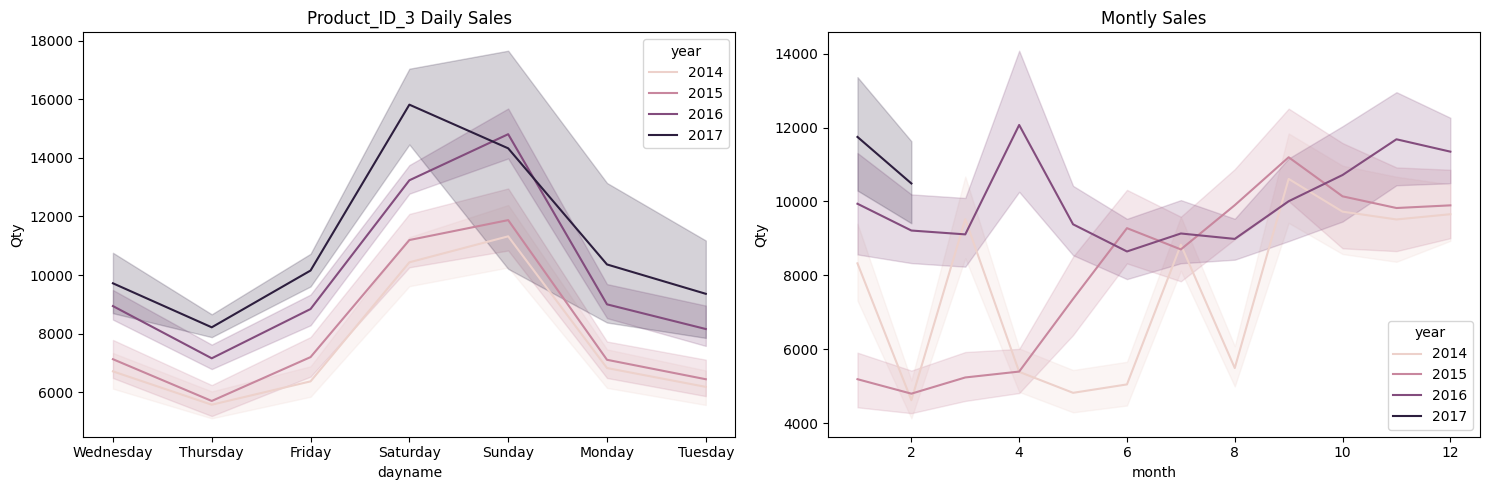

In [22]:
# 요일별 판매량 -> 주말, 주중 -> 요일과 판매량간 상관있어 요일 변수 추가, 분기는 관련 없음
Product_ID = 3
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.lineplot(x = 'dayname', y = 'Qty', hue = 'year', data = df)
plt.title(f'Product_ID_{Product_ID} Daily Sales')
plt.subplot(1,2,2)
sns.lineplot(x = 'month', y = 'Qty', hue = 'year', data = df)
plt.title('Montly Sales')
# sns.barplot(x = 'quarter', y = 'Qty', hue = 'year', data = df)
plt.tight_layout()
plt.show()

In [23]:
# Product_ID는 동일 카테고리 내 다른 상품 판매량 상관관계 낮음 -> 변수 제외
Product_ID = 3
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

category = products[products['Product_ID'] == Product_ID]['Category'].values[0]
same_cate = [i for i in products[products['Category'] == category]['Product_ID'].values if i != Product_ID]

import scipy.stats as spst
spst.pearsonr(func_preprocess(Product_ID = same_cate[0], Store_ID = Store_ID)['Qty'].values, func_preprocess(Product_ID = 3, Store_ID = Store_ID)['Qty'].values)

PearsonRResult(statistic=0.10220940653264268, pvalue=0.0005325158404958367)

PearsonRResult(statistic=0.45933676097653986, pvalue=8.780163066882768e-61)


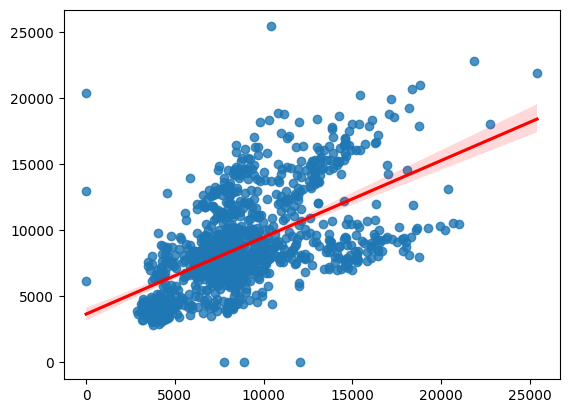

In [24]:
# 전일대비 판매량 증감과 당일 판매량 상관관계
print(spst.pearsonr(df['Qty'].diff().values[1:], df['Qty'].values[1:]))

# 전일 판매량과 당일 판매량 상관관계 -> 관련 있음 -> 변수 추가
spst.pearsonr(df['Qty'].shift(1).values[1:], df['Qty'].values[1:])
sns.regplot(x = df['Qty'].shift(1).values[1:], y = df['Qty'].values[1:], line_kws={'color': 'red'})
plt.show()

PearsonRResult(statistic=0.4803263305175383, pvalue=3.88528552472875e-67)


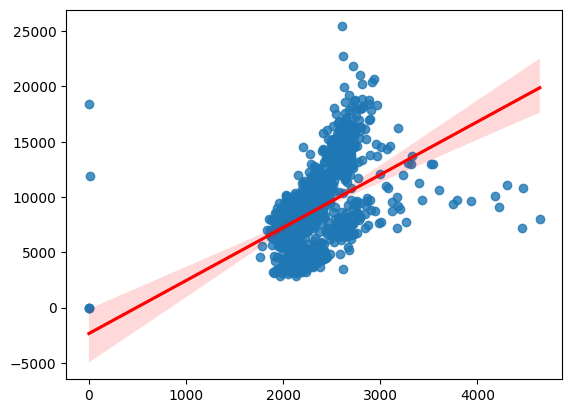

In [25]:
# 같은 지역 매장 고객 방문 수 -> 관련 있음 -> 변수 추가
region = stores[stores['Store_ID'] == 44]['State'].values[0] #\tMinnesota
same_region_ID = stores[stores['State'] == region]['Store_ID'].values
same_region_ID = [i for i in same_region_ID if i != 44]

same_region_cust = orders[orders['Store_ID'].isin(same_region_ID)].groupby('Date', as_index = False)['CustomerCount'].mean()
df = func_preprocess(Store_ID = 44, Product_ID = 3)
customer = pd.merge(df['Date'], same_region_cust, on = 'Date', how = 'left')
customer.fillna(0, inplace = True)
print(spst.pearsonr(customer['CustomerCount'].values, df['Qty'].values))

sns.regplot(x = customer['CustomerCount'].values, y = df['Qty'].values, line_kws={'color': 'red'})
plt.show()

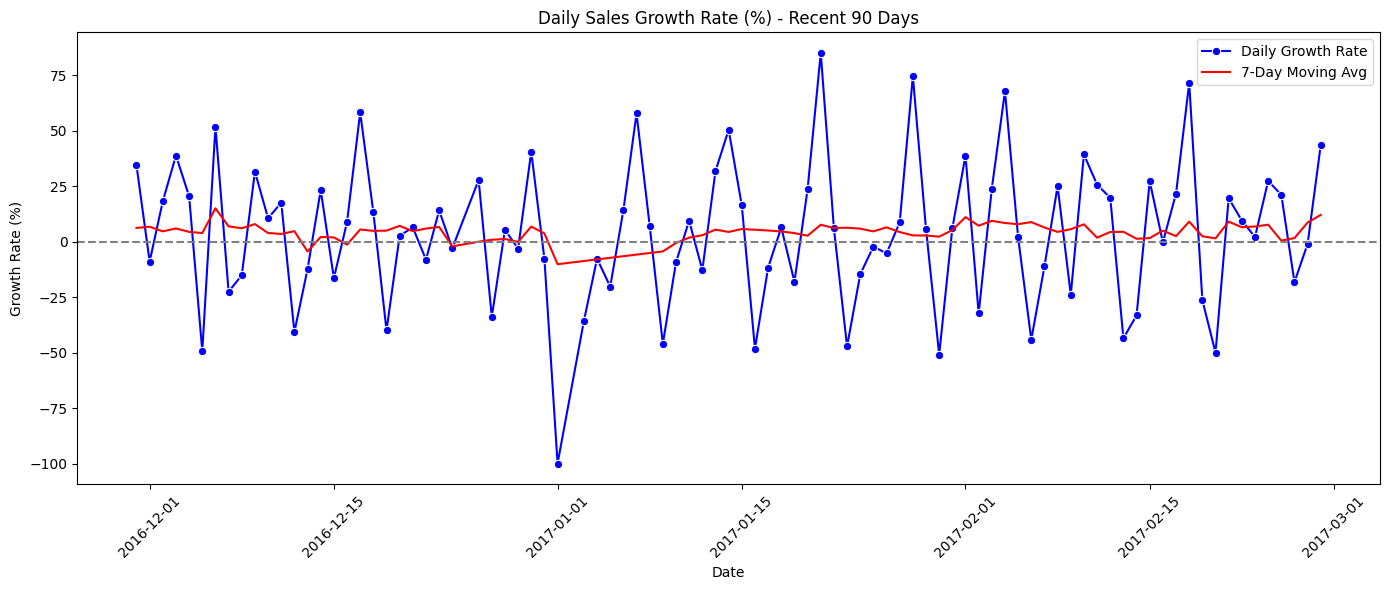

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 변화율과 이동 평균을 계산하기
df['qty_growth_rate'] = df['Qty'].pct_change() * 100  # 변화율 계산
df['moving_avg_growth_rate'] = df['qty_growth_rate'].rolling(window=7).mean()  # 7일 이동 평균

# 2. 최근 90일 데이터만 선택하기
start_date = df['Date'].max() - pd.Timedelta(days=90)  # 마지막 날짜 기준 90일 전부터
df_recent = df[df['Date'] >= start_date]  # 최근 90일 데이터로 필터링

# 3. 그래프 그리기
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_recent, x='Date', y='qty_growth_rate', marker='o', color='b', label='Daily Growth Rate')
sns.lineplot(data=df_recent, x='Date', y='moving_avg_growth_rate', color='r', label='7-Day Moving Avg')
plt.axhline(0, color='gray', linestyle='--')  # 0% 기준선 추가
plt.title("Daily Sales Growth Rate (%) - Recent 90 Days") #최근 90일 판매량 변화율 (%)
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


#### **(2) 상품 : 12 - Milk**

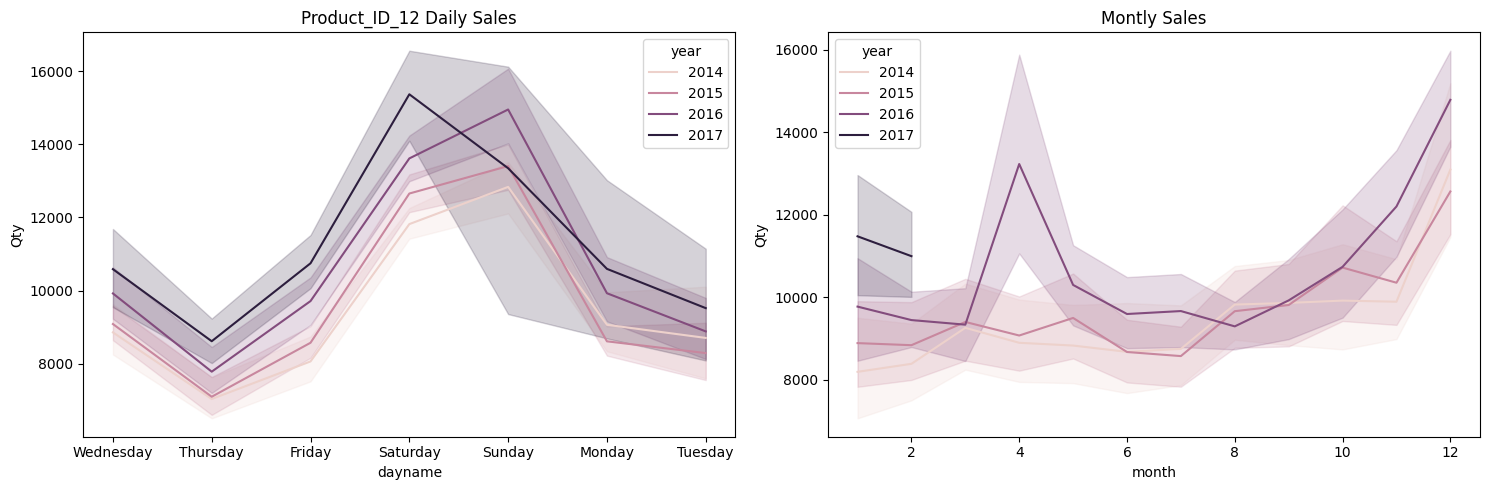

In [27]:
# 요일별 판매량 -> 주말, 주중 -> 요일과 판매량간 상관있어 요일 변수 추가, 분기는 관련 없음
Product_ID = 12
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.lineplot(x = 'dayname', y = 'Qty', hue = 'year', data = df)
plt.title(f'Product_ID_{Product_ID} Daily Sales')
plt.subplot(1,2,2)
sns.lineplot(x = 'month', y = 'Qty', hue = 'year', data = df)
plt.title('Montly Sales')
# sns.barplot(x = 'quarter', y = 'Qty', hue = 'year', data = df)
plt.tight_layout()
plt.show()

In [28]:
# Product_ID는 동일 카테고리 내 다른 상품 판매량 상관관계 낮음 -> 변수 제외
Product_ID = 12
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

category = products[products['Product_ID'] == Product_ID]['Category'].values[0]
same_cate = [i for i in products[products['Category'] == category]['Product_ID'].values if i != Product_ID]

import scipy.stats as spst
spst.pearsonr(func_preprocess(Product_ID = same_cate[0], Store_ID = Store_ID)['Qty'].values, func_preprocess(Product_ID = 12, Store_ID = Store_ID)['Qty'].values)

PearsonRResult(statistic=0.6245624162924802, pvalue=7.258227322318576e-125)

PearsonRResult(statistic=0.5376757016397747, pvalue=1.0614825279814342e-86)


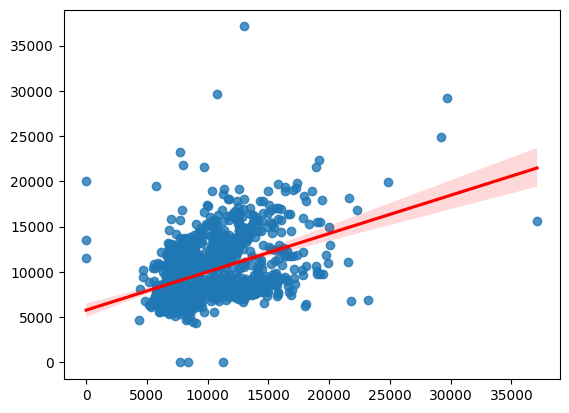

In [29]:
# 전일대비 판매량 증감과 당일 판매량 상관관계
print(spst.pearsonr(df['Qty'].diff().values[1:], df['Qty'].values[1:]))

# 전일 판매량과 당일 판매량 상관관계 -> 관련 있음 -> 변수 추가
spst.pearsonr(df['Qty'].shift(1).values[1:], df['Qty'].values[1:])
sns.regplot(x = df['Qty'].shift(1).values[1:], y = df['Qty'].values[1:], line_kws={'color': 'red'})
plt.show()

PearsonRResult(statistic=0.6394281804969083, pvalue=1.2133634780034834e-132)


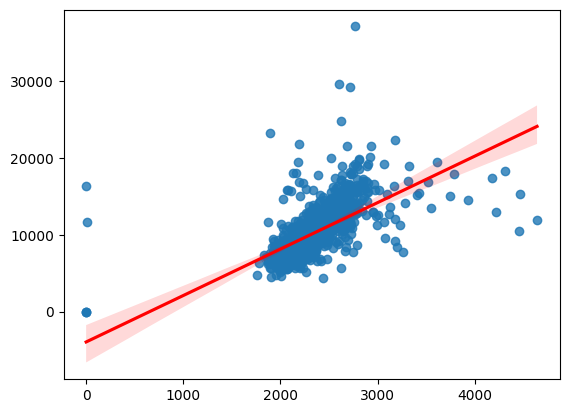

In [30]:
# 같은 지역 매장 고객 방문 수 -> 관련 있음 -> 변수 추가
region = stores[stores['Store_ID'] == 44]['State'].values[0] #\tMinnesota
same_region_ID = stores[stores['State'] == region]['Store_ID'].values
same_region_ID = [i for i in same_region_ID if i != 44]

same_region_cust = orders[orders['Store_ID'].isin(same_region_ID)].groupby('Date', as_index = False)['CustomerCount'].mean()
df = func_preprocess(Store_ID = 44, Product_ID = 12)
customer = pd.merge(df['Date'], same_region_cust, on = 'Date', how = 'left')
customer.fillna(0, inplace = True)
print(spst.pearsonr(customer['CustomerCount'].values, df['Qty'].values))

sns.regplot(x = customer['CustomerCount'].values, y = df['Qty'].values, line_kws={'color': 'red'})
plt.show()

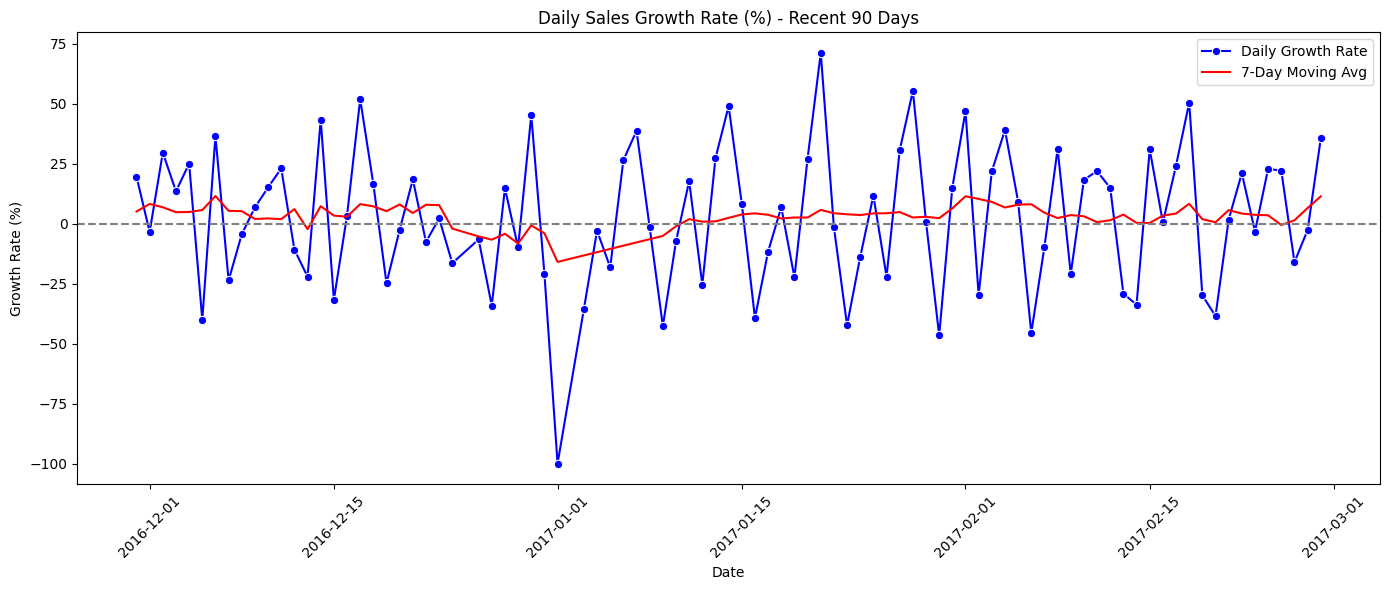

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 변화율과 이동 평균을 계산하기
df['qty_growth_rate'] = df['Qty'].pct_change() * 100  # 변화율 계산
df['moving_avg_growth_rate'] = df['qty_growth_rate'].rolling(window=7).mean()  # 7일 이동 평균

# 2. 최근 90일 데이터만 선택하기
start_date = df['Date'].max() - pd.Timedelta(days=90)  # 마지막 날짜 기준 90일 전부터
df_recent = df[df['Date'] >= start_date]  # 최근 90일 데이터로 필터링

# 3. 그래프 그리기
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_recent, x='Date', y='qty_growth_rate', marker='o', color='b', label='Daily Growth Rate')
sns.lineplot(data=df_recent, x='Date', y='moving_avg_growth_rate', color='r', label='7-Day Moving Avg')
plt.axhline(0, color='gray', linestyle='--')  # 0% 기준선 추가
plt.title("Daily Sales Growth Rate (%) - Recent 90 Days") #최근 90일 판매량 변화율 (%)
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


#### **(3) 상품 : 42 - Agricultural products**

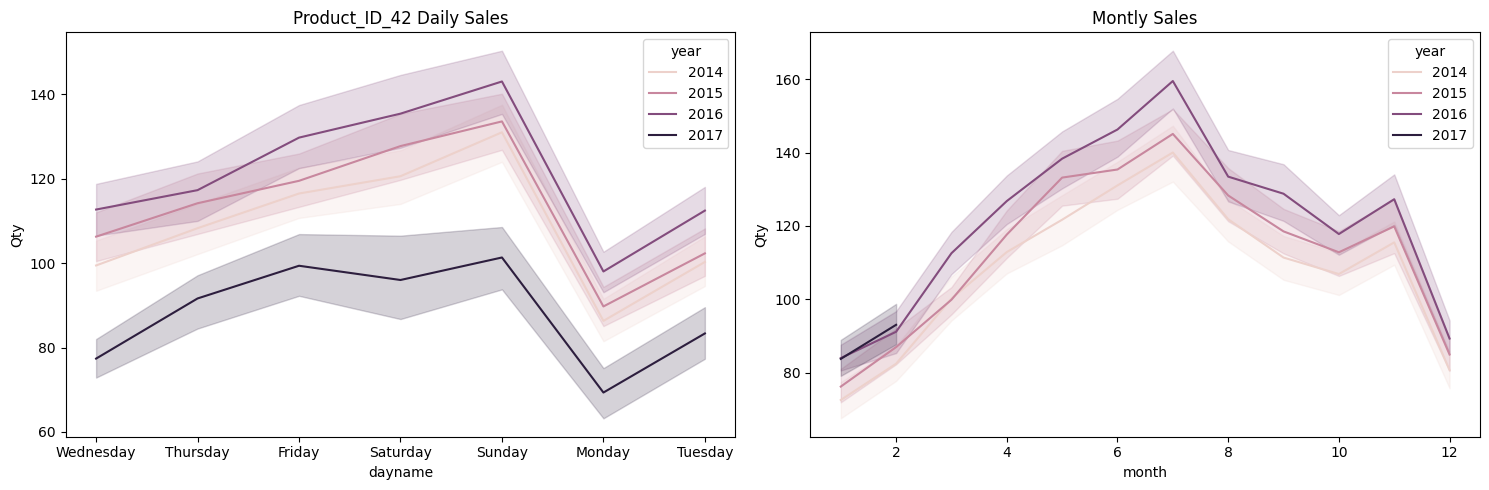

In [32]:
# 요일별 판매량 -> 주말, 주중 -> 요일과 판매량간 상관있어 요일 변수 추가, 분기는 관련 없음
Product_ID = 42
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.lineplot(x = 'dayname', y = 'Qty', hue = 'year', data = df)
plt.title(f'Product_ID_{Product_ID} Daily Sales')
plt.subplot(1,2,2)
sns.lineplot(x = 'month', y = 'Qty', hue = 'year', data = df)
plt.title('Montly Sales')
# sns.barplot(x = 'quarter', y = 'Qty', hue = 'year', data = df)
plt.tight_layout()
plt.show()

In [33]:
# Product_ID는 동일 카테고리 내 다른 상품 판매량 상관관계 낮음 -> 변수 제외
Product_ID = 42
Store_ID = 44
df = func_preprocess(Store_ID = Store_ID, Product_ID = Product_ID)

category = products[products['Product_ID'] == Product_ID]['Category'].values[0]
same_cate = [i for i in products[products['Category'] == category]['Product_ID'].values if i != Product_ID]

import scipy.stats as spst
spst.pearsonr(func_preprocess(Product_ID = same_cate[0], Store_ID = Store_ID)['Qty'].values, func_preprocess(Product_ID = 12, Store_ID = Store_ID)['Qty'].values)

PearsonRResult(statistic=0.4934365891324575, pvalue=2.6570246595506947e-71)

PearsonRResult(statistic=0.4259555280806475, pvalue=9.191402430186935e-52)


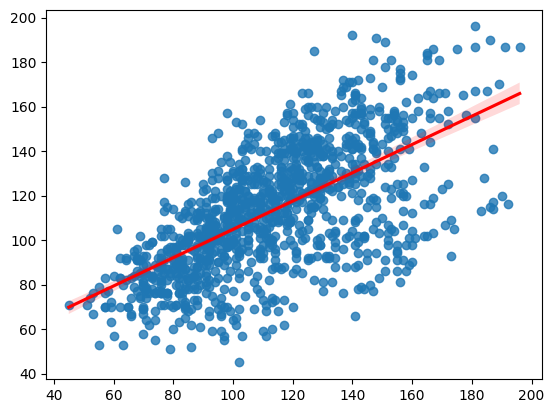

In [34]:
# 전일대비 판매량 증감과 당일 판매량 상관관계
print(spst.pearsonr(df['Qty'].diff().values[1:], df['Qty'].values[1:]))

# 전일 판매량과 당일 판매량 상관관계 -> 관련 있음 -> 변수 추가
spst.pearsonr(df['Qty'].shift(1).values[1:], df['Qty'].values[1:])
sns.regplot(x = df['Qty'].shift(1).values[1:], y = df['Qty'].values[1:], line_kws={'color': 'red'})
plt.show()

PearsonRResult(statistic=0.06804811711893409, pvalue=0.02112305386721886)


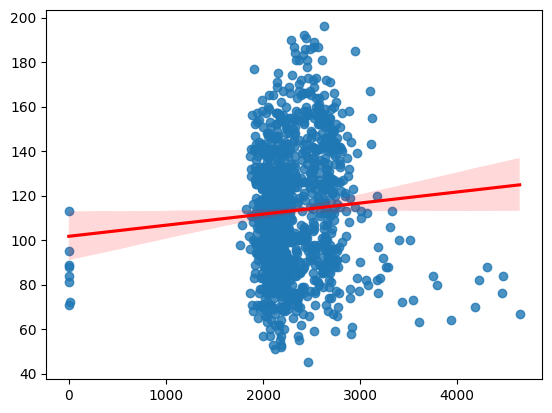

In [35]:
# 같은 지역 매장 고객 방문 수 -> 관련 있음 -> 변수 추가
region = stores[stores['Store_ID'] == 44]['State'].values[0] #\tMinnesota
same_region_ID = stores[stores['State'] == region]['Store_ID'].values
same_region_ID = [i for i in same_region_ID if i != 44]

same_region_cust = orders[orders['Store_ID'].isin(same_region_ID)].groupby('Date', as_index = False)['CustomerCount'].mean()
df = func_preprocess(Store_ID = 44, Product_ID = 42)
customer = pd.merge(df['Date'], same_region_cust, on = 'Date', how = 'left')
customer.fillna(0, inplace = True)
print(spst.pearsonr(customer['CustomerCount'].values, df['Qty'].values))

sns.regplot(x = customer['CustomerCount'].values, y = df['Qty'].values, line_kws={'color': 'red'})
plt.show()

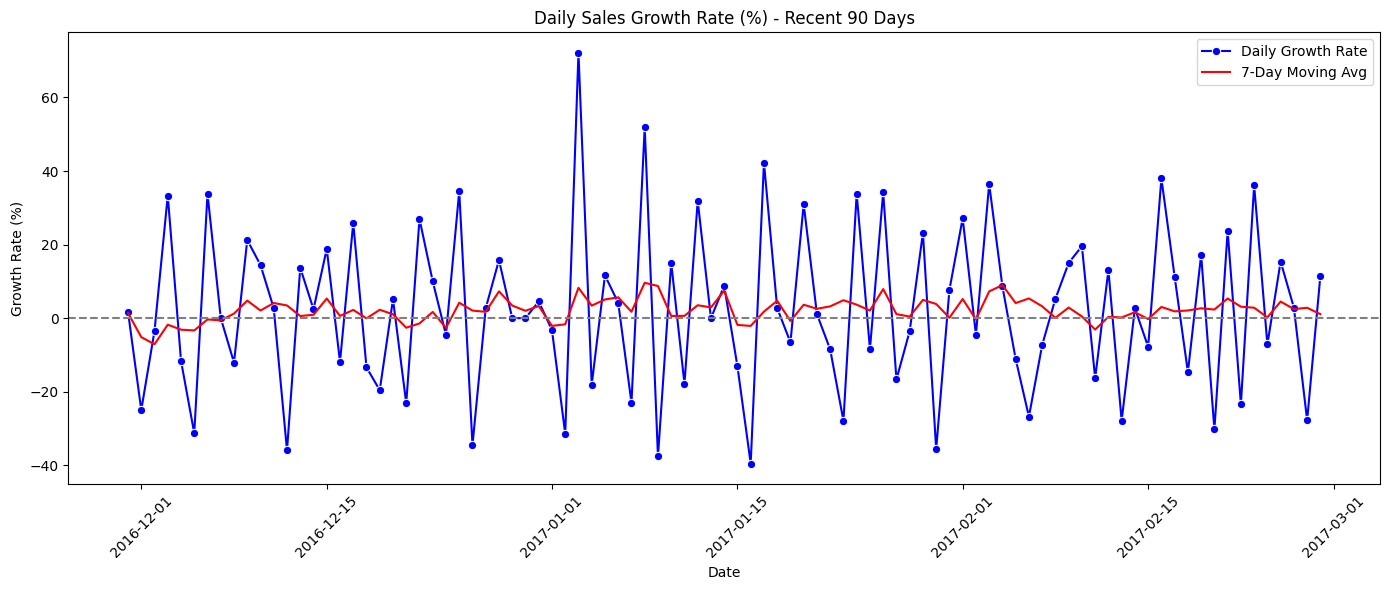

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 변화율과 이동 평균을 계산하기
df['qty_growth_rate'] = df['Qty'].pct_change() * 100  # 변화율 계산
df['moving_avg_growth_rate'] = df['qty_growth_rate'].rolling(window=7).mean()  # 7일 이동 평균

# 2. 최근 90일 데이터만 선택하기
start_date = df['Date'].max() - pd.Timedelta(days=90)  # 마지막 날짜 기준 90일 전부터
df_recent = df[df['Date'] >= start_date]  # 최근 90일 데이터로 필터링

# 3. 그래프 그리기
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_recent, x='Date', y='qty_growth_rate', marker='o', color='b', label='Daily Growth Rate')
sns.lineplot(data=df_recent, x='Date', y='moving_avg_growth_rate', color='r', label='7-Day Moving Avg')
plt.axhline(0, color='gray', linestyle='--')  # 0% 기준선 추가
plt.title("Daily Sales Growth Rate (%) - Recent 90 Days") #최근 90일 판매량 변화율 (%)
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# **3.Baseline Model**

* **세부 요구사항**
    * 데이터 준비
        * 스케일링
            * 교과서 적으로는 데이터 분할 이후 스케일링하는게 맞지만, 데이터 건수가 충분히 크다면, 스케일링을 먼저 하기도 합니다.
            * 여기서는 먼저 스케일링을 한 후 데이터 분할을 합니다.
        * 데이터 분할
            * 검증셋 구성 : 학습용 데이터에서 최근 60일을 검증셋으로 사용.

    * 모델링
        * Dense Layer 1개(output layer)만으로 모델을 생성합니다.
        * 모델의 검증 성능을 평가하고 기록합니다.
        * 평가 지표 : RMSE, MAE, MAPE, R2 Score


## **(1) 상품 : 3 - Beverage**

In [37]:
# 필요한 변수 추출
df = func_preprocess(Store_ID = 44, Product_ID = 3)[['Qty','CustomerCount','dayname','previous_qty','same_region_customer','weekend','MA7']]
df['target'] = df['Qty'].shift(-2)
# df['dayname'] = df['dayname'].shift(-2)
# df['weekend'] = df['weekend'].shift(-2)

# 변수명 변경
df.rename(columns = {'month':'Month', 'lastweek_qty':'LastWeekQty','previous_qty':'PrevQty',
                     'dayname':'WeekDay', 'weekend':'Weekend', 'same_region_customer':'SameRegionCustomer'}, inplace = True)

# 하위 2행 제외 (Nan 값이므로)
df = df[:-2]

# 가변수화
df = pd.get_dummies(df, columns = ['WeekDay','Weekend'], drop_first = True, dtype = int)

# weekend_주중 : 1, 주말 : 0으로 되어 있어 -> 주말 : 1로 변경
df['Weekend_주말'] = df['Weekend_주중'].map({1:0, 0:1})
df.drop(columns = 'Weekend_주중', inplace = True)

# x, y 분리
target = 'target'
x = df.drop(columns = target)
y = df.loc[:, target]

# 스케일링
scaler = MinMaxScaler()
x_s = scaler = scaler.fit_transform(x)

y_max, y_min = y.max(), y.min()
y_s = (y-y_min)/(y_max-y_min)

Product_ID = 3

# 데이터프레임 저장
joblib.dump(df, f'df_{Product_ID}.pkl')
df = joblib.load(f'df_{Product_ID}.pkl')

In [38]:
df.head()

,Qty,CustomerCount,PrevQty,SameRegionCustomer,MA7,target,WeekDay_Monday,WeekDay_Saturday,WeekDay_Sunday,WeekDay_Thursday,WeekDay_Tuesday,WeekDay_Wednesday,Weekend_주말
0,8800.0,4254.0,7188.0,2264.0,15606.0,7051.0,0,0,0,0,0,1,0
1,6606.0,3723.0,8800.0,2094.0,15606.0,12599.0,0,0,0,1,0,0,0
2,7051.0,4010.0,6606.0,2179.0,15606.0,13383.0,0,0,0,0,0,0,0
3,12599.0,5053.0,7051.0,2720.0,15606.0,7086.0,0,1,0,0,0,0,1
4,13383.0,4852.0,12599.0,2678.0,13383.0,5821.0,0,0,1,0,0,0,1


In [39]:
# 시계열 데이터 전처리 2차원 --> 3차원으로 변환
def temporalize(x, y, timesteps):
    nfeature = x.shape[1]
    output_x = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        t = []
        for j in range(timesteps):
            t.append(x[[(i + j)], :])
        output_x.append(t)
        output_y.append(y[i + timesteps - 1])
    return np.array(output_x).reshape(-1,timesteps, nfeature), np.array(output_y)

timestep = 14
x2, y2 = temporalize(x_s, y_s, timestep)
x2.shape, y2.shape

((1130, 14, 12), (1130,))

In [40]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x2, y2, test_size=120, shuffle = False) # 0.2, 55*4
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1010, 14, 12), (1010,), (120, 14, 12), (120,))

### **3-1.LSTM**

In [41]:
timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]

# clear_session()
model1 = Sequential([Input(shape = (timesteps, nfeatures)),
                     LSTM(4, return_sequences=True),
                     Dropout(0.2),
                     Flatten(),
                     Dense(4, activation = 'relu'),
                     Dense(1)])

es = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
model1.compile(optimizer=Adam(learning_rate = 0.01), loss='mse')
hist = model1.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks=[es]).history

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0989 - val_loss: 0.0382
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0136 - val_loss: 0.0125
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 0.0127
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0120
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0092
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0114
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - val_loss: 0.0111
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0096
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053 - val_loss: 0.0100
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0068 - val_loss: 0.0115
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0056 - val_loss: 0.0097
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

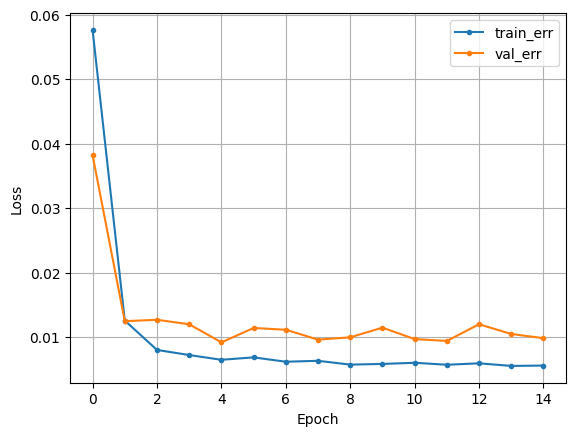

In [42]:
dl_history_plot(hist)

In [43]:
# 예측
pred1 = model1.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred1 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1540 차이 난다.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
MAE:1677.1534301757813
RMSE:2434.6222992157063
MAPE:4.737383287226368e+17
R2_Score:0.5408979329899533


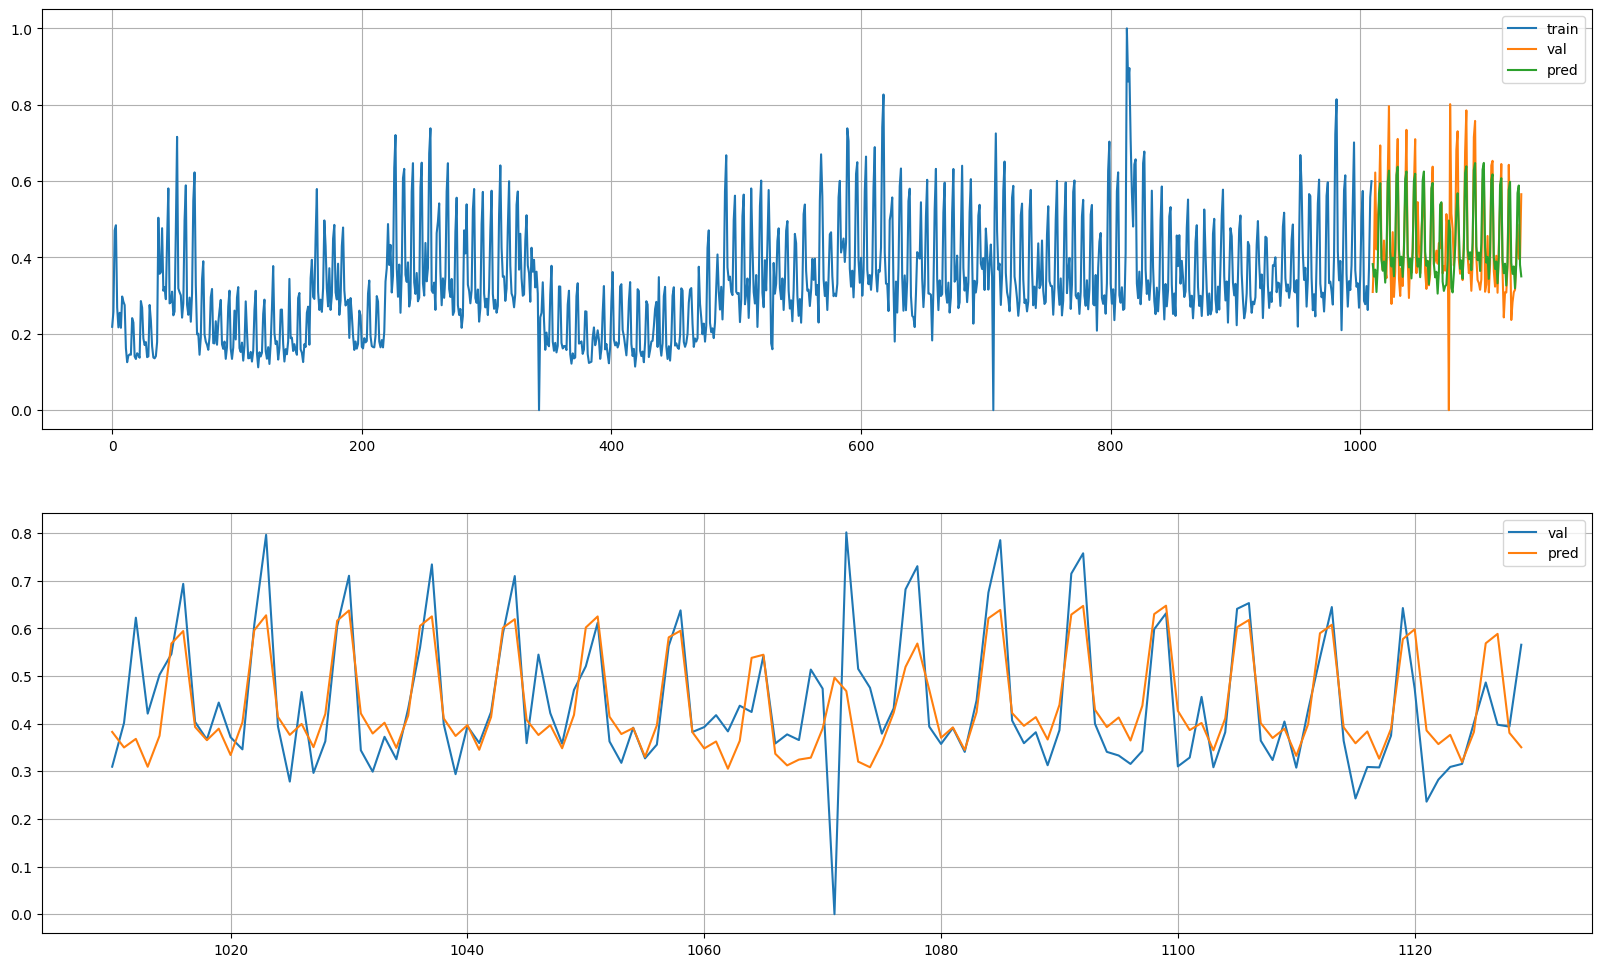

In [44]:
plot_model_result(y_train, y_val, pred1)

### **3-2.RNN**

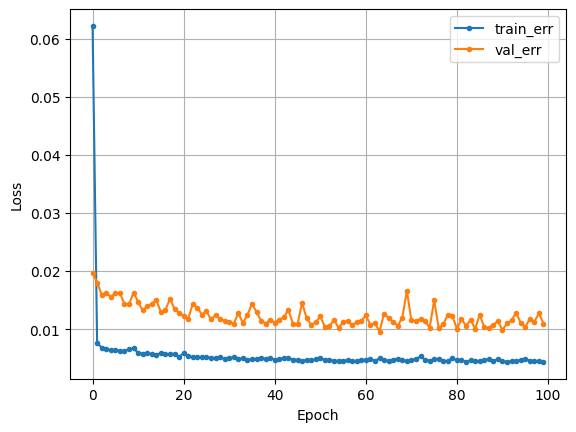

In [45]:
#clear_session()

model = Sequential([Input(shape = (timesteps, nfeatures)),
                    SimpleRNN(8),
                    Dense(1)])

model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'mse')
hist = model.fit(x_train, y_train, epochs = 100, verbose = 0, validation_data = (x_val, y_val)).history
dl_history_plot(hist)

In [46]:
# 예측
pred2 = model.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred2 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1714 차이 난다.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
MAE:1745.1427408854167
RMSE:2659.636435097852
MAPE:4.7786179052989754e+17
R2_Score:0.45211349332041784


## **(2) 상품 : 12 - Milk**

In [47]:
# 필요한 변수 추출
df = func_preprocess(Store_ID = 44, Product_ID = 12)[['Qty','CustomerCount','dayname','previous_qty','same_region_customer','weekend','MA7']]
df['target'] = df['Qty'].shift(-2)
# df['dayname'] = df['dayname'].shift(-2)
# df['weekend'] = df['weekend'].shift(-2)

# 변수명 변경
df.rename(columns = {'month':'Month', 'lastweek_qty':'LastWeekQty','previous_qty':'PrevQty',
                     'dayname':'WeekDay', 'weekend':'Weekend', 'same_region_customer':'SameRegionCustomer'}, inplace = True)

# 하위 2행 제외 (Nan 값이므로)
df = df[:-2]

# 가변수화
df = pd.get_dummies(df, columns = ['WeekDay','Weekend'], drop_first = True, dtype = int)

# weekend_주중 : 1, 주말 : 0으로 되어 있어 -> 주말 : 1로 변경
df['Weekend_주말'] = df['Weekend_주중'].map({1:0, 0:1})
df.drop(columns = 'Weekend_주중', inplace = True)

# x, y 분리
target = 'target'
x = df.drop(columns = target)
y = df.loc[:, target]

# 스케일링
scaler = MinMaxScaler()
x_s = scaler = scaler.fit_transform(x)

y_max, y_min = y.max(), y.min()
y_s = (y-y_min)/(y_max-y_min)

Product_ID = 12

# 데이터프레임 저장
joblib.dump(df, f'df_{Product_ID}.pkl')
df = joblib.load(f'df_{Product_ID}.pkl')

In [48]:
df.head()

,Qty,CustomerCount,PrevQty,SameRegionCustomer,MA7,target,WeekDay_Monday,WeekDay_Saturday,WeekDay_Sunday,WeekDay_Thursday,WeekDay_Tuesday,WeekDay_Wednesday,Weekend_주말
0,8683.0,4254.0,7124.0,2264.0,14490.0,6992.0,0,0,0,0,0,1,0
1,6731.0,3723.0,8683.0,2094.0,14490.0,11224.0,0,0,0,1,0,0,0
2,6992.0,4010.0,6731.0,2179.0,14490.0,11536.0,0,0,0,0,0,0,0
3,11224.0,5053.0,6992.0,2720.0,14490.0,6948.0,0,1,0,0,0,0,1
4,11536.0,4852.0,11224.0,2678.0,11536.0,5710.0,0,0,1,0,0,0,1


In [49]:
# 시계열 데이터 전처리 2차원 --> 3차원으로 변환
def temporalize(x, y, timesteps):
    nfeature = x.shape[1]
    output_x = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        t = []
        for j in range(timesteps):
            t.append(x[[(i + j)], :])
        output_x.append(t)
        output_y.append(y[i + timesteps - 1])
    return np.array(output_x).reshape(-1,timesteps, nfeature), np.array(output_y)

timestep = 14
x2, y2 = temporalize(x_s, y_s, timestep)
x2.shape, y2.shape

((1130, 14, 12), (1130,))

In [50]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x2, y2, test_size=120, shuffle = False) # 0.2, 55*4
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1010, 14, 12), (1010,), (120, 14, 12), (120,))

### **3-1.LSTM**

In [51]:
timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]

# clear_session()
model1 = Sequential([Input(shape = (timesteps, nfeatures)),
                     LSTM(4, return_sequences=True),
                     Dropout(0.2),
                     Flatten(),
                     Dense(4, activation = 'relu'),
                     Dense(1)])

es = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
model1.compile(optimizer=Adam(learning_rate = 0.01), loss='mse')
hist = model1.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks=[es]).history

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0227 - val_loss: 0.0137
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0067 - val_loss: 0.0114
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0128
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0047 - val_loss: 0.0109
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0095
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0099
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 0.0072
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052 - val_loss: 0.0095
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - val_loss: 0.0096
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - val_loss: 0.0072
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0048 - val_loss: 0.0080
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

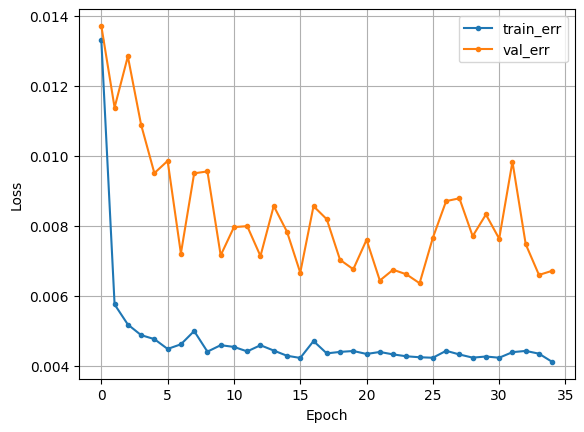

In [52]:
dl_history_plot(hist)

In [53]:
# 예측
pred1 = model1.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred1 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1540 차이 난다.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
MAE:2097.8909993489583
RMSE:2958.5094212785407
MAPE:5.820426063337663e+17
R2_Score:0.3805293207369804


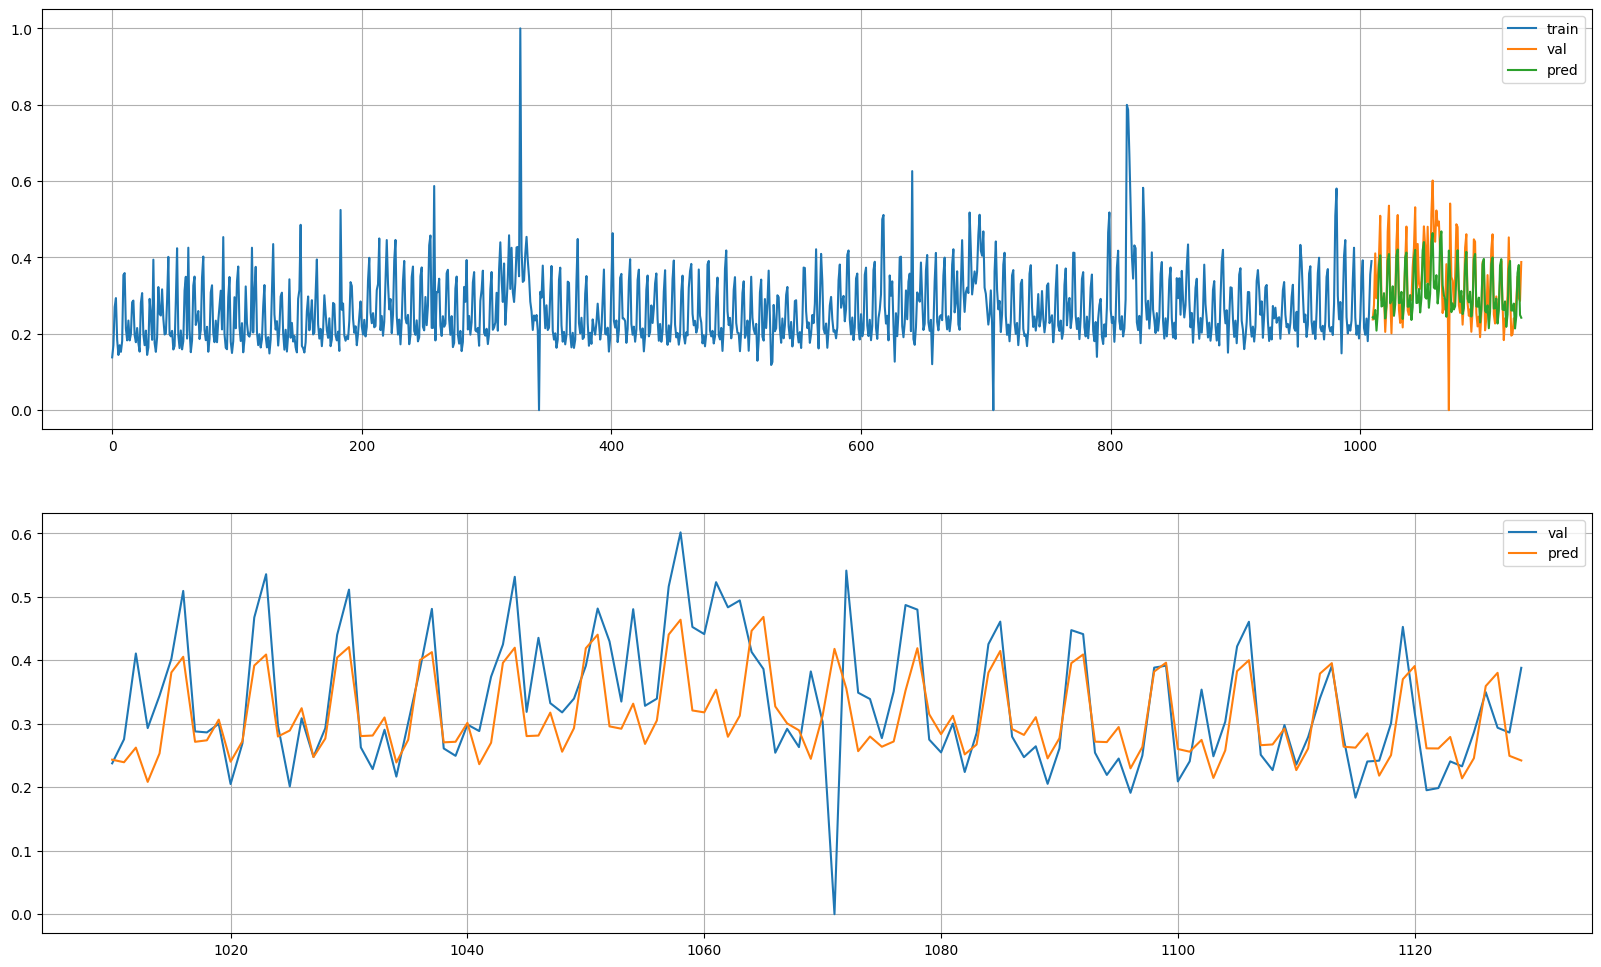

In [54]:
plot_model_result(y_train, y_val, pred1)

### **3-2.RNN**

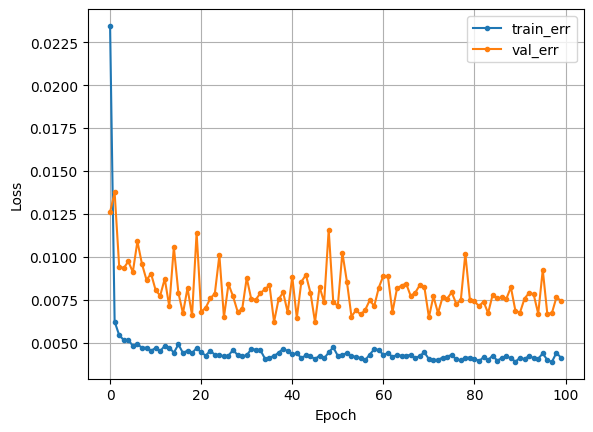

In [55]:
#clear_session()

model = Sequential([Input(shape = (timesteps, nfeatures)),
                    SimpleRNN(8),
                    Dense(1)])

model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'mse')
hist = model.fit(x_train, y_train, epochs = 100, verbose = 0, validation_data = (x_val, y_val)).history
dl_history_plot(hist)

In [56]:
# 예측
pred2 = model.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred2 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1714 차이 난다.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
MAE:2166.530476888021
RMSE:3201.627242716714
MAPE:5.7473811078579923e+17
R2_Score:0.27453514923153377


## **(3) 상품 : 42 - Agricultural products**

In [57]:
# 필요한 변수 추출
df = func_preprocess(Store_ID = 44, Product_ID = 42)[['Qty','CustomerCount','dayname','previous_qty','same_region_customer','weekend','MA7']]
df['target'] = df['Qty'].shift(-2)
# df['dayname'] = df['dayname'].shift(-2)
# df['weekend'] = df['weekend'].shift(-2)

# 변수명 변경
df.rename(columns = {'month':'Month', 'lastweek_qty':'LastWeekQty','previous_qty':'PrevQty',
                     'dayname':'WeekDay', 'weekend':'Weekend', 'same_region_customer':'SameRegionCustomer'}, inplace = True)

# 하위 2행 제외 (Nan 값이므로)
df = df[:-2]

# 가변수화
df = pd.get_dummies(df, columns = ['WeekDay','Weekend'], drop_first = True, dtype = int)

# weekend_주중 : 1, 주말 : 0으로 되어 있어 -> 주말 : 1로 변경
df['Weekend_주말'] = df['Weekend_주중'].map({1:0, 0:1})
df.drop(columns = 'Weekend_주중', inplace = True)

# x, y 분리
target = 'target'
x = df.drop(columns = target)
y = df.loc[:, target]

# 스케일링
scaler = MinMaxScaler()
x_s = scaler = scaler.fit_transform(x)

y_max, y_min = y.max(), y.min()
y_s = (y-y_min)/(y_max-y_min)

Product_ID = 42

# 데이터프레임 저장
joblib.dump(df, f'df_{Product_ID}.pkl')
df = joblib.load(f'df_{Product_ID}.pkl')

In [58]:
df.head()

,Qty,CustomerCount,PrevQty,SameRegionCustomer,MA7,target,WeekDay_Monday,WeekDay_Saturday,WeekDay_Sunday,WeekDay_Thursday,WeekDay_Tuesday,WeekDay_Wednesday,Weekend_주말
0,73.0,4254.0,78.0,2264.0,88.0,96.0,0,0,0,0,0,1,0
1,78.0,3723.0,73.0,2094.0,88.0,67.0,0,0,0,1,0,0,0
2,96.0,4010.0,78.0,2179.0,96.0,93.0,0,0,0,0,0,0,0
3,67.0,5053.0,96.0,2720.0,96.0,59.0,0,1,0,0,0,0,1
4,93.0,4852.0,67.0,2678.0,96.0,63.0,0,0,1,0,0,0,1


In [59]:
# 시계열 데이터 전처리 2차원 --> 3차원으로 변환
def temporalize(x, y, timesteps):
    nfeature = x.shape[1]
    output_x = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        t = []
        for j in range(timesteps):
            t.append(x[[(i + j)], :])
        output_x.append(t)
        output_y.append(y[i + timesteps - 1])
    return np.array(output_x).reshape(-1,timesteps, nfeature), np.array(output_y)

timestep = 14
x2, y2 = temporalize(x_s, y_s, timestep)
x2.shape, y2.shape

((1133, 14, 12), (1133,))

In [60]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x2, y2, test_size=120, shuffle = False) # 0.2, 55*4
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((1013, 14, 12), (1013,), (120, 14, 12), (120,))

### **3-1.LSTM**

In [61]:
timesteps = x_train.shape[1]
nfeatures = x_train.shape[2]

# clear_session()
model1 = Sequential([Input(shape = (timesteps, nfeatures)),
                     LSTM(4, return_sequences=True),
                     Dropout(0.2),
                     Flatten(),
                     Dense(4, activation = 'relu'),
                     Dense(1)])

es = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
model1.compile(optimizer=Adam(learning_rate = 0.01), loss='mse')
hist = model1.fit(x_train, y_train, epochs = 100, validation_data=(x_val, y_val), callbacks=[es]).history

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0527 - val_loss: 0.0129
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0154 - val_loss: 0.0106
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0098 - val_loss: 0.0103
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0089 - val_loss: 0.0096
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0091 - val_loss: 0.0087
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0083 - val_loss: 0.0096
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_loss: 0.0095
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - val_loss: 0.0084
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - los

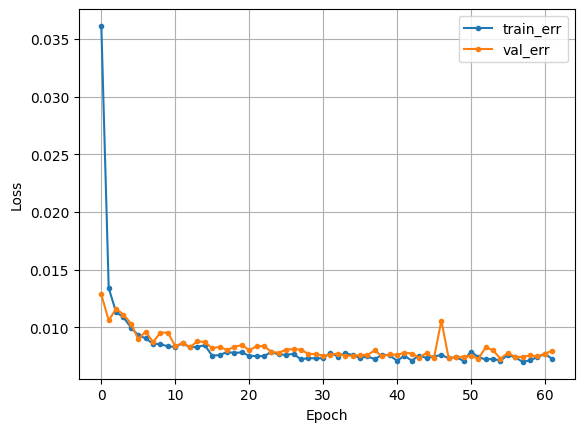

In [62]:
dl_history_plot(hist)

In [63]:
# 예측
pred1 = model1.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred1 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1540 차이 난다.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
MAE:9.722401936848959
RMSE:12.880658658999828
MAPE:0.10239660911600544
R2_Score:0.6896867567721862


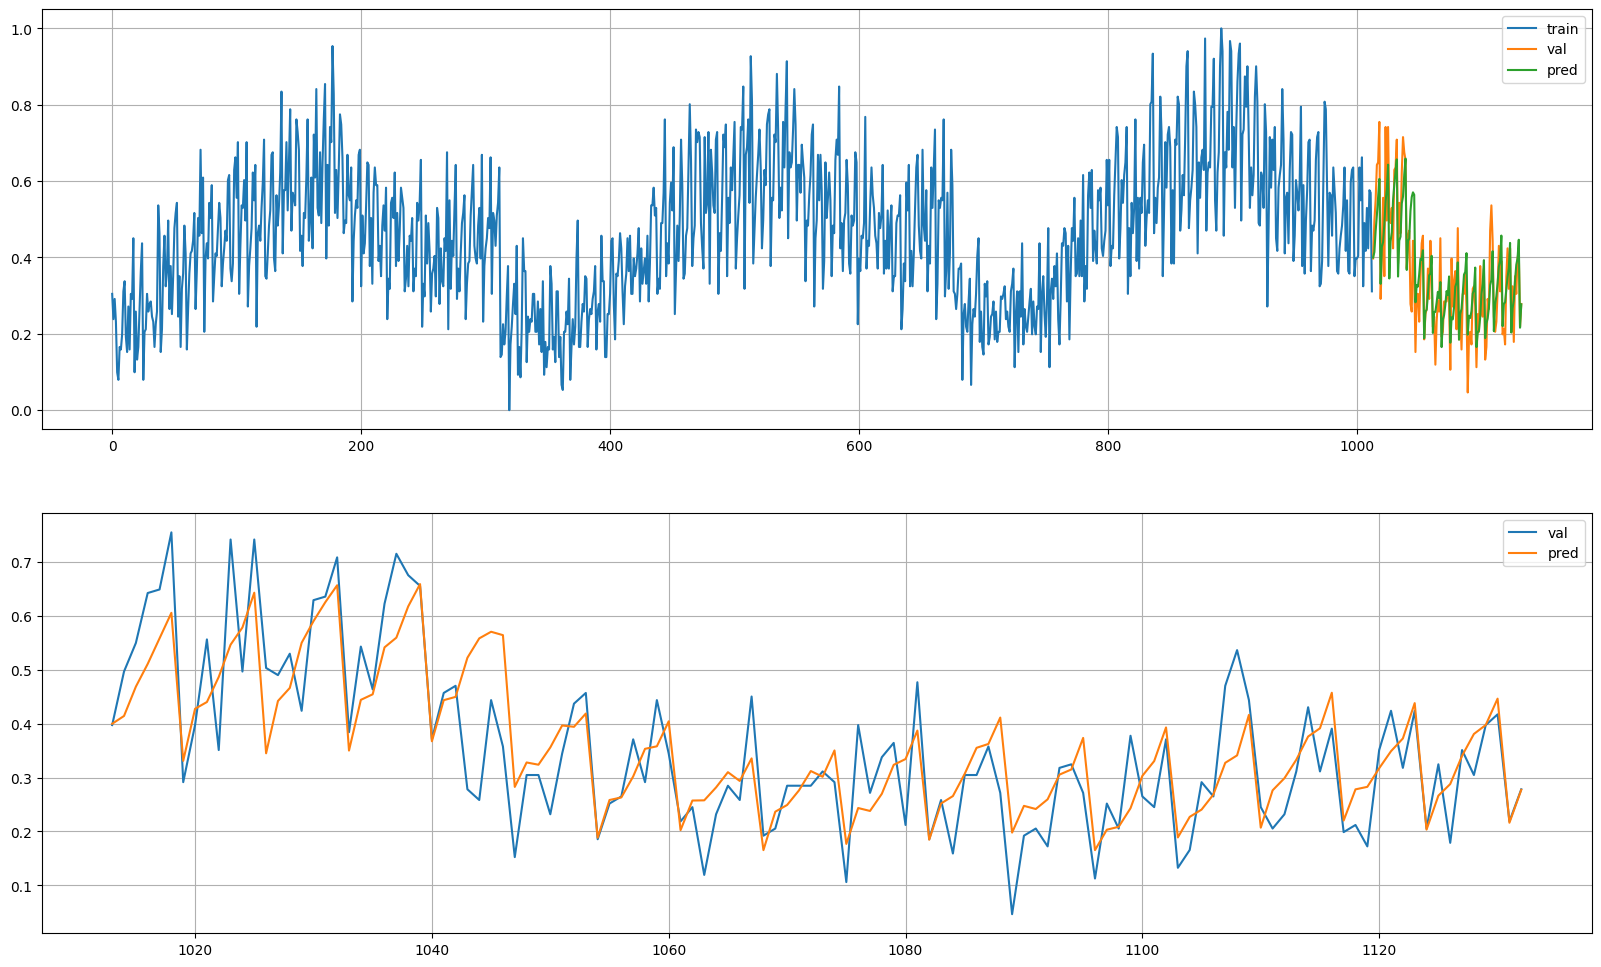

In [64]:
plot_model_result(y_train, y_val, pred1)

### **3-2.RNN**

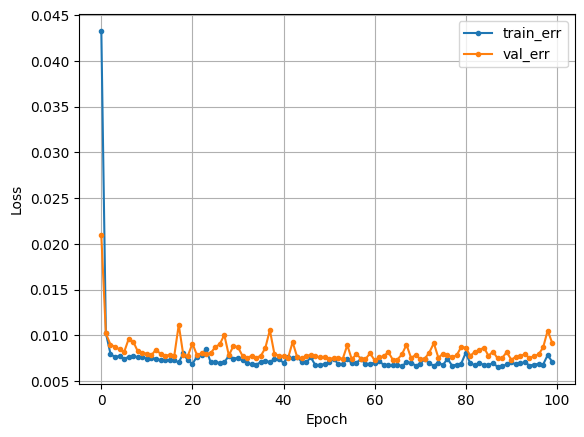

In [65]:
#clear_session()

model = Sequential([Input(shape = (timesteps, nfeatures)),
                    SimpleRNN(8),
                    Dense(1)])

model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'mse')
hist = model.fit(x_train, y_train, epochs = 100, verbose = 0, validation_data = (x_val, y_val)).history
dl_history_plot(hist)

In [66]:
# 예측
pred2 = model.predict(x_val)

# y를 원래대로 돌려 놓기
y_val_real = y_val * (y_max - y_min) + y_min
pred_real  = pred2 * (y_max - y_min) + y_min

print(f'MAE:{mean_absolute_error(y_val_real, pred_real)}')
print(f'RMSE:{root_mean_squared_error(y_val_real, pred_real)}')
print(f'MAPE:{mean_absolute_percentage_error(y_val_real, pred_real)}')
print(f'R2_Score:{r2_score(y_val_real, pred_real)}')
#이틀 후의 판매량을 예측할 때 오차가 1714 차이 난다.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
MAE:10.91503849029541
RMSE:14.456255219839086
MAPE:0.11762635183958373
R2_Score:0.6091269017095443
